# Original Paper Follow-up

Expanded generator comparison using the original revision tests, with all t-SNE analyses omitted.

Methods: Bootstrap, Column-wise, GMM, SMOTE, GMM-guided SMOTE, and CVAE.

## Setup and run configuration

`preview` is intended for checking the complete workflow. Change `RUN_MODE` to `final` for paper-quality repeat counts and longer neural-network training.

In [1]:
from pathlib import Path
import hashlib
import importlib
import pickle
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parents[1]
pkg_root = repo_root / "data_synthesis"
if str(pkg_root) not in sys.path:
    sys.path.insert(0, str(pkg_root))

from src.revision import data_io
from src import original_paper_followup as followup
followup = importlib.reload(followup)

RUN_MODE = "final" 
FORCE_RECOMPUTE = False
SEED = 42
RUNS = {
    "preview": dict(cvae_epochs=25, auc_repeats=3, tstr_repeats=2,
                    noise_repeats=2, ablation_repeats=2, sample_repeats=1,
                    sample_cvae_epochs=15),
    "final": dict(cvae_epochs=200, auc_repeats=50, tstr_repeats=20,
                  noise_repeats=5, ablation_repeats=20, sample_repeats=5,
                  sample_cvae_epochs=100),
}
cfg = RUNS[RUN_MODE]
datasets, dataset_summary = data_io.initialize_datasets()
METHODS = followup.METHOD_ORDER

cache_dir = pkg_root / "notebooks" / "followup_cache"
cache_dir.mkdir(parents=True, exist_ok=True)
fingerprint = hashlib.sha1(repr((RUN_MODE, SEED, cfg, METHODS)).encode()).hexdigest()[:10]

def cached(name, builder):
    path = cache_dir / f"{name}_{fingerprint}.pkl"
    if path.exists() and not FORCE_RECOMPUTE:
        with path.open("rb") as handle:
            return pickle.load(handle)
    value = builder()
    with path.open("wb") as handle:
        pickle.dump(value, handle)
    return value

print(f"Run mode: {RUN_MODE} | methods: {', '.join(METHODS)}")
display(dataset_summary)

Run mode: final | methods: Bootstrap, Column-wise, GMM, SMOTE, GMM-guided SMOTE, CVAE


,dataset,samples,features,class_0,class_1
0,HIV,91,63,23,68
1,Breast Cancer,569,30,212,357
2,Diabetes,768,8,500,268


## Generate matched synthetic cohorts

Every generator produces the original class counts. The cohorts are cached and reused across tests so each comparison sees the same synthetic observations.

In [2]:
cohorts = cached(
    "cohorts",
    lambda: followup.generate_cohorts(
        datasets,
        methods=METHODS,
        seed=SEED,
        cvae_epochs=cfg["cvae_epochs"],
    ),
)
cohort_summary = pd.DataFrame([
    {"dataset": dataset, "method": method, "synthetic_rows": len(values[1]),
     "features": values[0].shape[1], "class_0": int((values[1] == 0).sum()),
     "class_1": int((values[1] == 1).sum())}
    for dataset, method_data in cohorts.items()
    for method, values in method_data.items()
])
display(cohort_summary)

,dataset,method,synthetic_rows,features,class_0,class_1
0,HIV,Bootstrap,91,63,23,68
1,HIV,Column-wise,91,63,23,68
2,HIV,GMM,91,63,23,68
3,HIV,SMOTE,91,63,23,68
4,HIV,GMM-guided SMOTE,91,63,23,68
5,HIV,CVAE,91,63,23,68
6,Breast Cancer,Bootstrap,569,30,212,357
7,Breast Cancer,Column-wise,569,30,212,357
8,Breast Cancer,GMM,569,30,212,357
9,Breast Cancer,SMOTE,569,30,212,357


## Feature-wise KLD

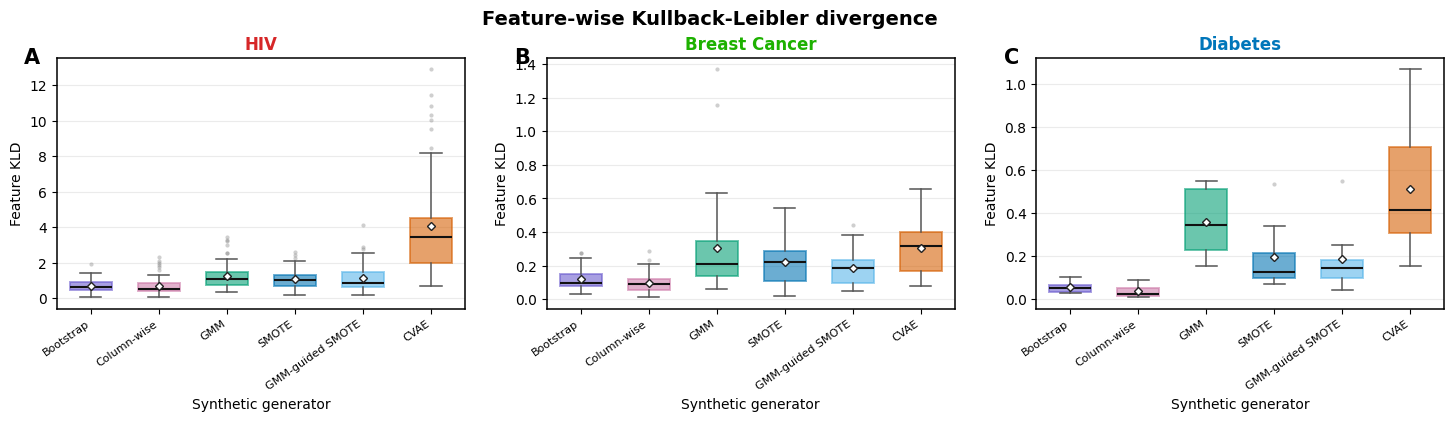

,dataset,method,mean,std,median
0,Breast Cancer,Bootstrap,0.119875,0.068055,0.098453
1,Breast Cancer,CVAE,0.303677,0.144956,0.314283
2,Breast Cancer,Column-wise,0.096551,0.063317,0.087772
3,Breast Cancer,GMM,0.302857,0.291767,0.206403
4,Breast Cancer,GMM-guided SMOTE,0.185602,0.105058,0.184460
5,Breast Cancer,SMOTE,0.223329,0.144460,0.219129
6,Diabetes,Bootstrap,0.052020,0.026596,0.047698
7,Diabetes,CVAE,0.511692,0.323173,0.413748
8,Diabetes,Column-wise,0.033843,0.031660,0.019414
9,Diabetes,GMM,0.358579,0.156133,0.344551


In [3]:
feature_kld = cached(
    "feature_kld",
    lambda: followup.compute_feature_kld_table(datasets, cohorts),
)
fig_kld = followup.plot_feature_kld_boxplots(feature_kld)
plt.show()
display(
    feature_kld.groupby(["dataset", "method"])["kld"]
    .agg(mean="mean", std="std", median="median")
    .reset_index()
)

## PCA comparison

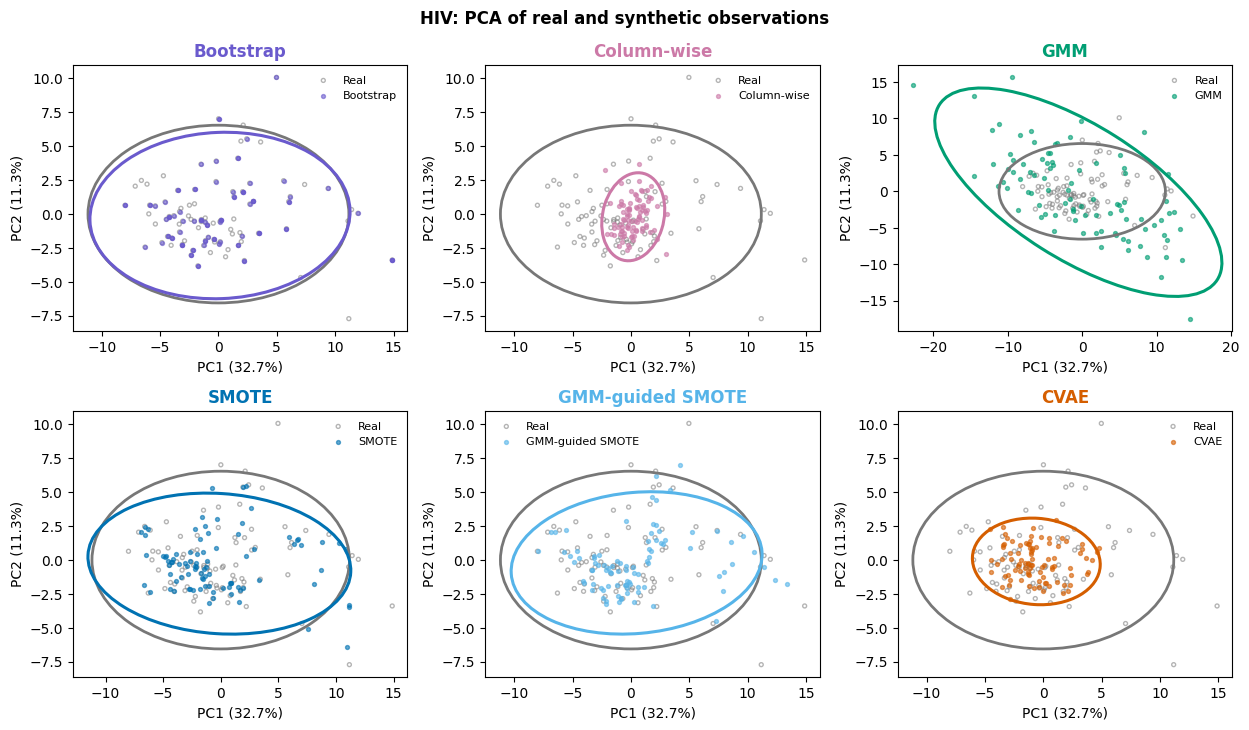

In [4]:
PCA_DATASET = "HIV"  # "HIV", "Breast Cancer", or "Diabetes"
fig_pca = followup.plot_pca_grid(datasets, cohorts, PCA_DATASET)
plt.show()

## Real-versus-synthetic origin AUC

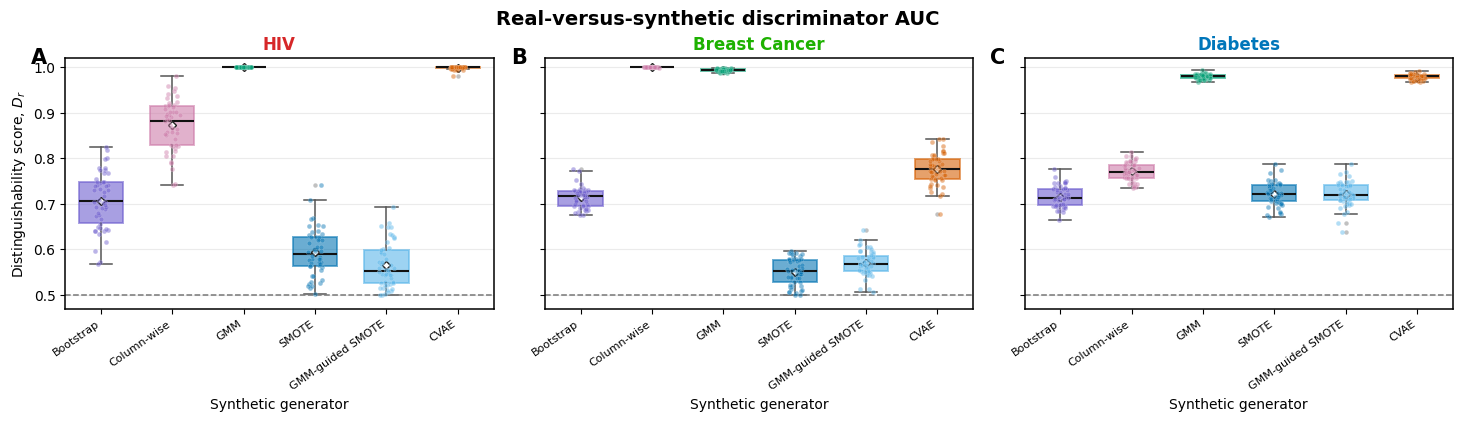

,dataset,method,mean,std
0,Breast Cancer,Bootstrap,0.713883,0.022244
1,Breast Cancer,CVAE,0.776239,0.033675
2,Breast Cancer,Column-wise,0.999670,0.000292
3,Breast Cancer,GMM,0.993406,0.002752
4,Breast Cancer,GMM-guided SMOTE,0.570363,0.027090
5,Breast Cancer,SMOTE,0.550698,0.028809
6,Diabetes,Bootstrap,0.715744,0.022990
7,Diabetes,CVAE,0.978508,0.005656
8,Diabetes,Column-wise,0.771039,0.019893
9,Diabetes,GMM,0.979513,0.005173


In [5]:
auc_runs = cached(
    "origin_auc",
    lambda: followup.compute_origin_auc(
        datasets, cohorts, repeats=cfg["auc_repeats"], seed=SEED
    ),
)
auc_summary = (auc_runs.groupby(["dataset", "method"])["separability_auc"]
               .agg(mean="mean", std="std").reset_index())
fig1_auc = followup.plot_figure1_auc_boxplots(auc_runs)
plt.show()
display(auc_summary)

## Utility and distributional fidelity

This retains TSTR F1, the absolute TRTR–TSTR utility gap, mean per-feature KLD and KS, and nearest-neighbor realism distance.

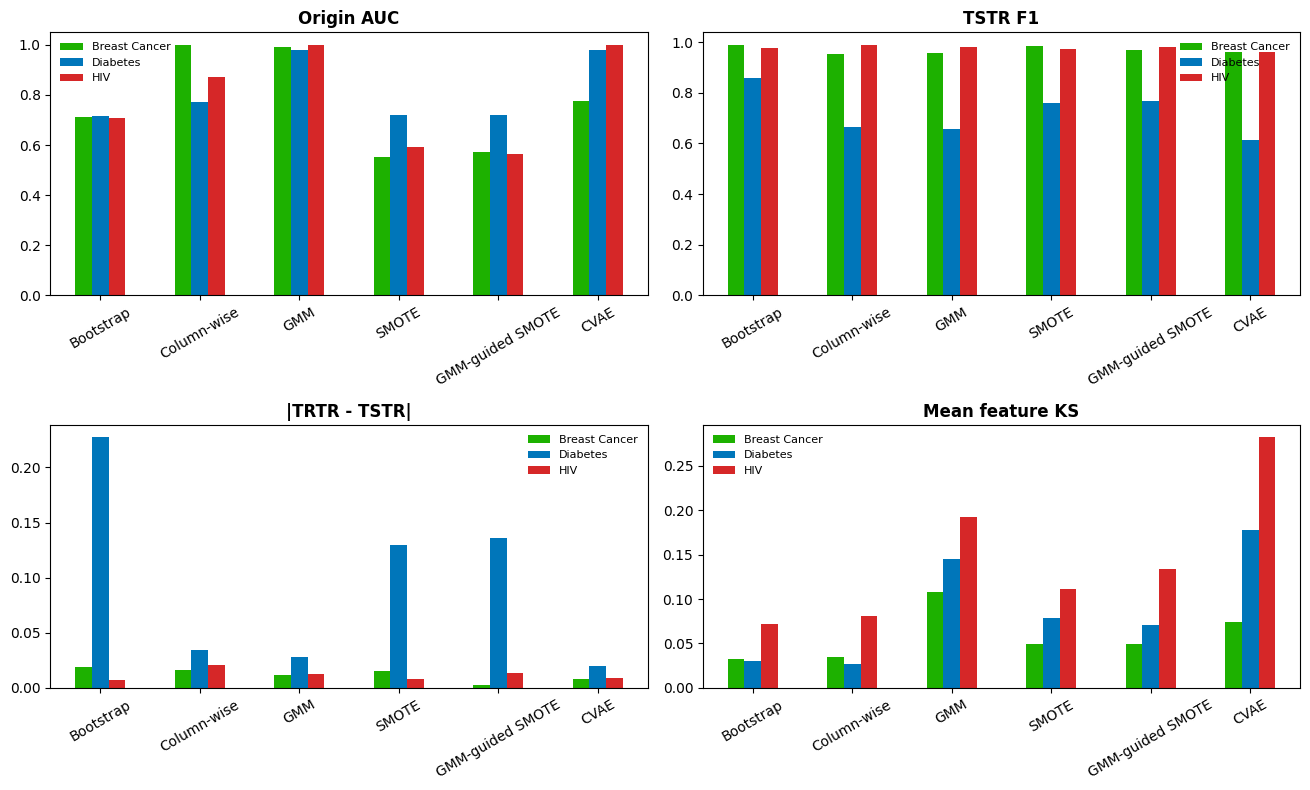

,dataset,method,origin_auc_mean,origin_auc_sd,tstr_f1_mean,tstr_f1_sd,utility_gap_abs_mean,mean_feature_kld,mean_feature_ks,nn_distance_mean
6,Breast Cancer,Bootstrap,0.713883,0.022020,0.988304,0.001117,0.019226,0.119875,0.032689,1.563776e-08
11,Breast Cancer,CVAE,0.776239,0.033336,0.960971,0.001771,0.008107,0.303677,0.073989,1.924033e+00
7,Breast Cancer,Column-wise,0.999670,0.000289,0.952673,0.001655,0.016405,0.096551,0.035267,4.038053e+00
8,Breast Cancer,GMM,0.993406,0.002724,0.957316,0.001194,0.011763,0.302857,0.107557,5.611696e+00
10,Breast Cancer,GMM-guided SMOTE,0.570363,0.026818,0.970245,0.001715,0.002760,0.185602,0.049326,1.035988e+00
9,Breast Cancer,SMOTE,0.550698,0.028520,0.984319,0.001456,0.015241,0.223329,0.049619,1.110558e+00
12,Diabetes,Bootstrap,0.715744,0.022759,0.856925,0.003559,0.227309,0.052020,0.030436,0.000000e+00
17,Diabetes,CVAE,0.978508,0.005600,0.612922,0.008452,0.020066,0.511692,0.177246,9.429189e-01
13,Diabetes,Column-wise,0.771039,0.019693,0.663631,0.005046,0.034016,0.033843,0.026693,1.337459e+00
14,Diabetes,GMM,0.979513,0.005121,0.657554,0.005948,0.027939,0.358579,0.145020,1.333848e+00


In [6]:
metric_table = cached(
    "metric_table",
    lambda: followup.compute_metric_table(
        datasets, cohorts, auc_runs,
        tstr_repeats=cfg["tstr_repeats"], seed=SEED,
    ),
)
fig_metrics = followup.plot_metric_summary(metric_table)
plt.show()
display(metric_table.sort_values(["dataset", "method"]))

## Conditional-dependence structure

Graphical Lasso precision matrices are compared using Frobenius deviation, real-edge recovery, and the synthetic-only edge rate. The categorical edge-status matrix is retained; coordinate-embedding and cluster-layout analyses are omitted.

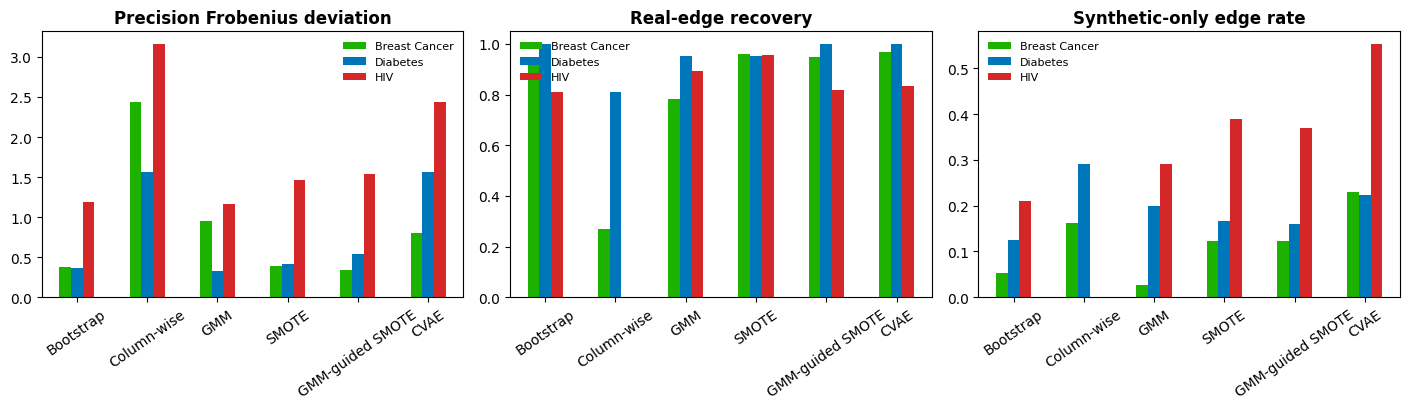

,dataset,method,frobenius_deviation,edge_recovery,synthetic_only_rate,real_edges,synthetic_edges
6,Breast Cancer,Bootstrap,0.378561,0.927835,0.052632,97,95
11,Breast Cancer,CVAE,0.803565,0.969072,0.229508,97,122
7,Breast Cancer,Column-wise,2.432675,0.268041,0.161290,97,31
8,Breast Cancer,GMM,0.956552,0.783505,0.025641,97,78
10,Breast Cancer,GMM-guided SMOTE,0.344851,0.948454,0.123810,97,105
9,Breast Cancer,SMOTE,0.383069,0.958763,0.122642,97,106
12,Diabetes,Bootstrap,0.370135,1.000000,0.125000,21,24
17,Diabetes,CVAE,1.561114,1.000000,0.222222,21,27
13,Diabetes,Column-wise,1.561421,0.809524,0.291667,21,24
14,Diabetes,GMM,0.320984,0.952381,0.200000,21,25


In [7]:
structure_table = cached(
    "structure_table",
    lambda: followup.compute_structure_metrics(datasets, cohorts),
)
fig_structure = followup.plot_structure_metrics(structure_table)
plt.show()
display(structure_table.sort_values(["dataset", "method"]))

C:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -6.141e-04
  warnings.warn(


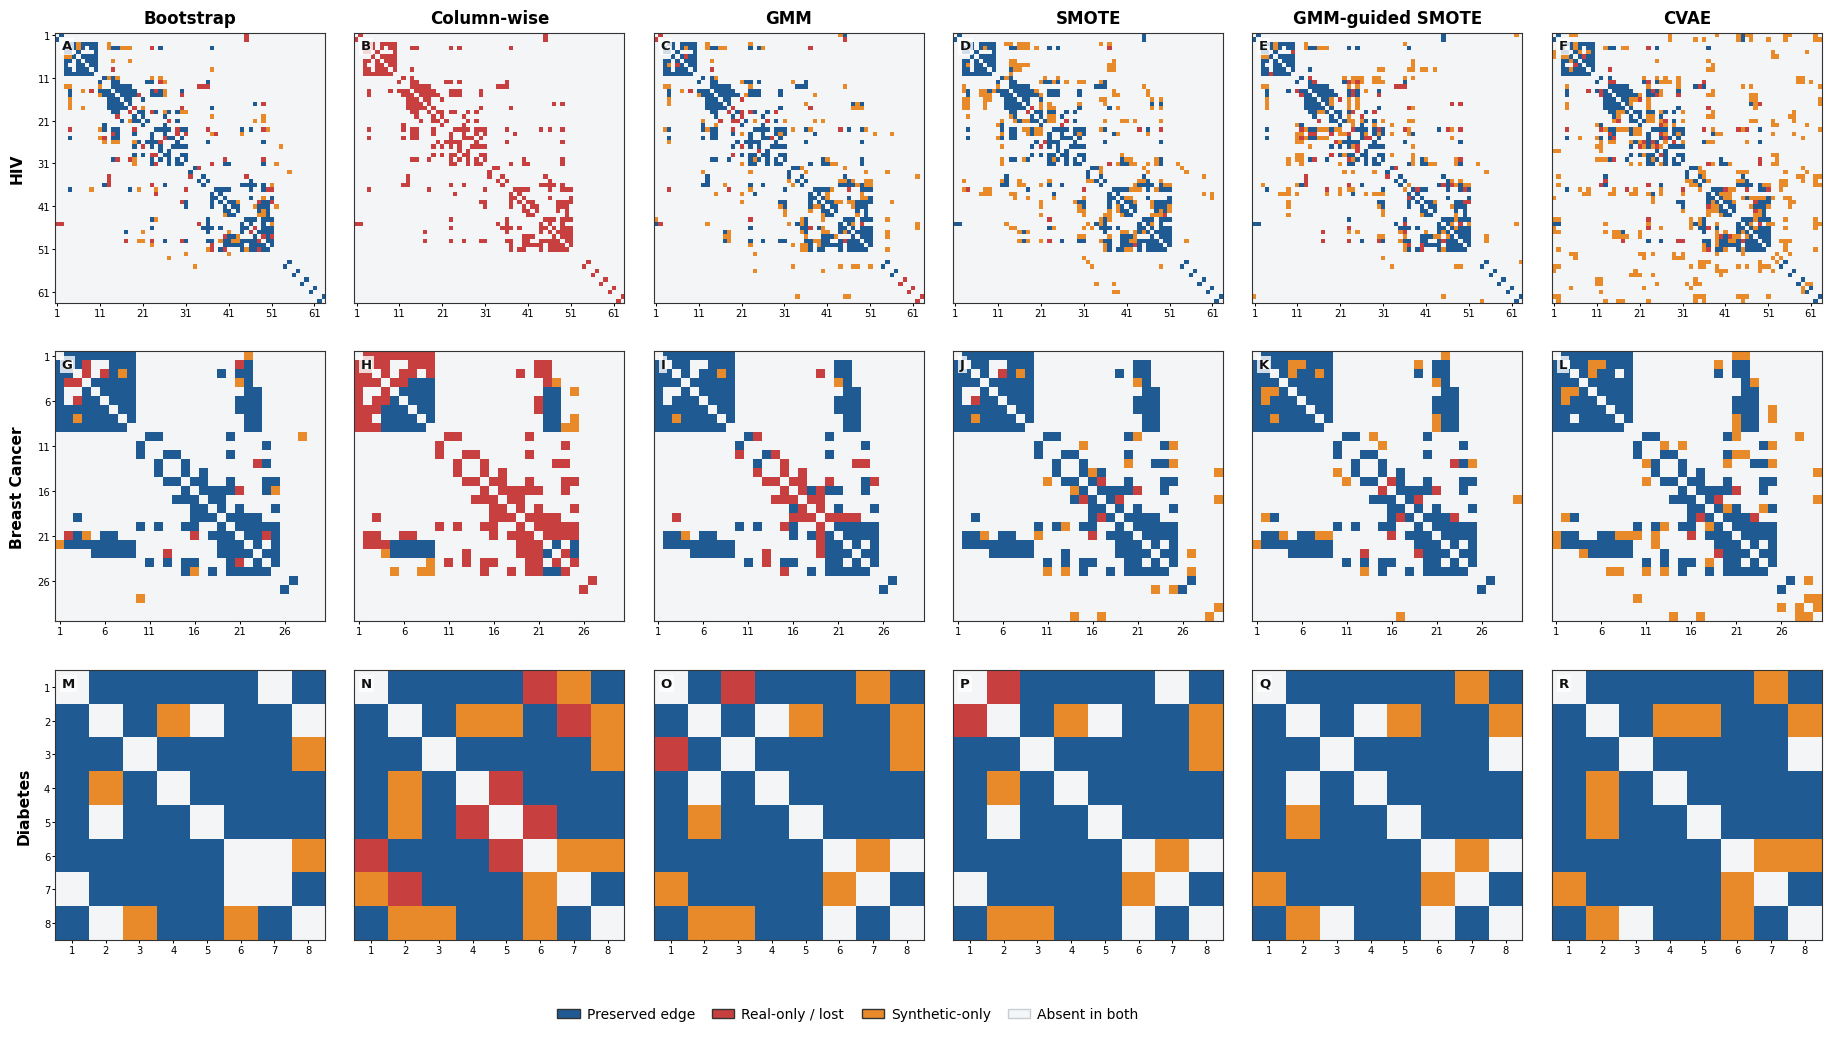

,dataset,method,frobenius_deviation,edge_recovery,synthetic_only_rate,n_real_edges,n_synthetic_edges
6,Breast Cancer,Bootstrap,0.378561,0.927835,0.052632,97,95
11,Breast Cancer,CVAE,0.803565,0.969072,0.229508,97,122
7,Breast Cancer,Column-wise,2.432675,0.268041,0.161290,97,31
8,Breast Cancer,GMM,0.956552,0.783505,0.025641,97,78
10,Breast Cancer,GMM-guided SMOTE,0.344851,0.948454,0.123810,97,105
9,Breast Cancer,SMOTE,0.383069,0.958763,0.122642,97,106
12,Diabetes,Bootstrap,0.370135,1.000000,0.125000,21,24
17,Diabetes,CVAE,1.561114,1.000000,0.222222,21,27
13,Diabetes,Column-wise,1.561421,0.809524,0.291667,21,24
14,Diabetes,GMM,0.320984,0.952381,0.200000,21,25


In [8]:
from src.revision.figure4_graphical_lasso_plots import plot_figure4_edge_status_all_datasets

real_data = {name: data["X"] for name, data in datasets.items()}
synthetic_data = {
    name: {method: values[0] for method, values in method_data.items()}
    for name, method_data in cohorts.items()
}
feature_names = {name: data["feature_names"] for name, data in datasets.items()}
edge_status = plot_figure4_edge_status_all_datasets(
    real_data=real_data,
    synthetic_data=synthetic_data,
    feature_names=feature_names,
    alphas=followup.FIGURE4_ALPHAS,
    dataset_order=list(datasets),
    method_order=METHODS,
    comparison_methods=METHODS,
)
plt.show()
display(edge_status.metrics.sort_values(["dataset", "method"]))

## Marginal fidelity diagnostics

Welch tests and KS statistics are retained for every feature and method.

In [9]:
marginal_tests = cached(
    "marginal_tests",
    lambda: followup.compute_marginal_tests(datasets, cohorts),
)
marginal_summary = followup.summarize_marginal_tests(marginal_tests)
display(marginal_summary.sort_values(["dataset", "method"]))
display(marginal_tests.sort_values(["dataset", "method", "p_value"]).head(50))

,dataset,method,features_tested,features_p_below_0_05,median_p_value,mean_ks_statistic,percent_p_below_0_05
0,Breast Cancer,Bootstrap,30,0,0.791700,0.032689,0.000000
1,Breast Cancer,CVAE,30,0,0.499086,0.073989,0.000000
2,Breast Cancer,Column-wise,30,0,0.661491,0.035267,0.000000
3,Breast Cancer,GMM,30,0,0.721013,0.107557,0.000000
4,Breast Cancer,GMM-guided SMOTE,30,0,0.701803,0.049326,0.000000
5,Breast Cancer,SMOTE,30,0,0.612889,0.049619,0.000000
6,Diabetes,Bootstrap,8,0,0.593233,0.030436,0.000000
7,Diabetes,CVAE,8,0,0.355777,0.177246,0.000000
8,Diabetes,Column-wise,8,0,0.760369,0.026693,0.000000
9,Diabetes,GMM,8,0,0.722668,0.145020,0.000000


,dataset,method,feature,t_statistic,p_value,ks_statistic
388,Breast Cancer,Bootstrap,radius error,1.596665,0.110626,0.061511
390,Breast Cancer,Bootstrap,perimeter error,1.374058,0.169704,0.045694
391,Breast Cancer,Bootstrap,area error,1.362115,0.173453,0.049209
406,Breast Cancer,Bootstrap,worst symmetry,-0.922983,0.356212,0.040422
399,Breast Cancer,Bootstrap,worst texture,-0.736557,0.461544,0.035149
382,Breast Cancer,Bootstrap,mean smoothness,0.580376,0.561776,0.024605
397,Breast Cancer,Bootstrap,fractal dimension error,0.561861,0.574324,0.033392
379,Breast Cancer,Bootstrap,mean texture,-0.547895,0.583872,0.029877
396,Breast Cancer,Bootstrap,symmetry error,-0.516690,0.605473,0.026362
395,Breast Cancer,Bootstrap,concave points error,0.509766,0.610315,0.022847


## Noise sensitivity

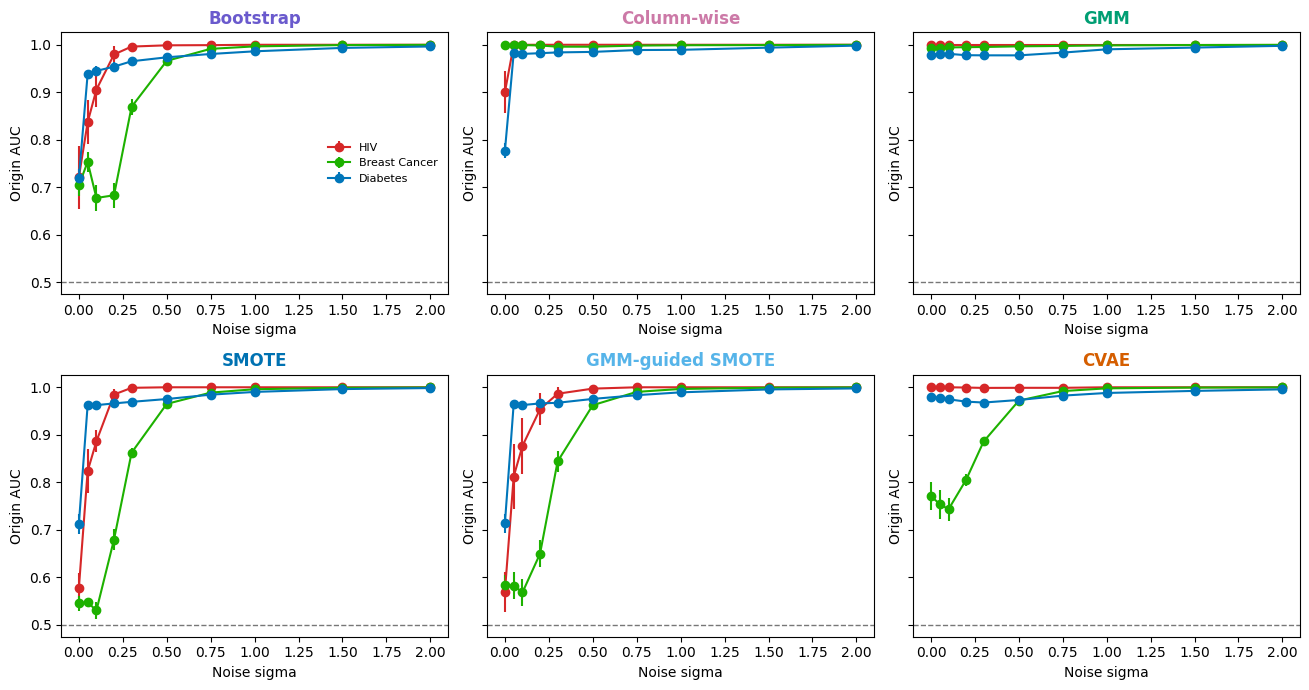

,dataset,method,sigma,sep_mean,sep_sd
0,HIV,Bootstrap,0.00,0.720983,0.066296
1,HIV,Bootstrap,0.05,0.836862,0.046572
2,HIV,Bootstrap,0.10,0.905671,0.037686
3,HIV,Bootstrap,0.20,0.979584,0.018805
4,HIV,Bootstrap,0.30,0.996219,0.004311
...,...,...,...,...,...
175,Diabetes,CVAE,0.50,0.973250,0.006204
176,Diabetes,CVAE,0.75,0.982406,0.003480
177,Diabetes,CVAE,1.00,0.988032,0.004972
178,Diabetes,CVAE,1.50,0.992372,0.002197


In [10]:
noise_table = cached(
    "noise_table",
    lambda: followup.compute_noise_sensitivity(
        datasets, cohorts,
        sigmas=(0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0),
        repeats=cfg["noise_repeats"], seed=SEED,
    ),
)
fig_noise = followup.plot_noise_sensitivity(noise_table)
plt.show()
display(noise_table)

## Reverse ablation

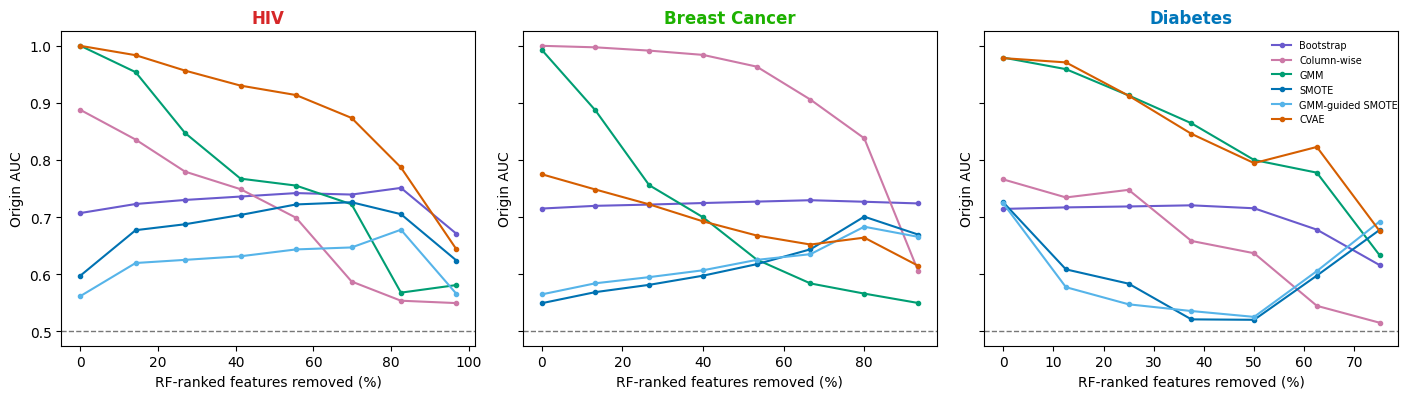

,dataset,method,n_features_removed,percent_removed,auc_mean,auc_sd
0,HIV,Bootstrap,0,0.000000,0.707042,0.050726
1,HIV,Bootstrap,9,14.285714,0.722921,0.042702
2,HIV,Bootstrap,17,26.984127,0.730009,0.043676
3,HIV,Bootstrap,26,41.269841,0.735964,0.046252
4,HIV,Bootstrap,35,55.555556,0.742013,0.046548
...,...,...,...,...,...,...
133,Diabetes,CVAE,2,25.000000,0.912377,0.017934
134,Diabetes,CVAE,3,37.500000,0.845726,0.018306
135,Diabetes,CVAE,4,50.000000,0.794468,0.021594
136,Diabetes,CVAE,5,62.500000,0.822744,0.015510


In [11]:
ablation_table = cached(
    "reverse_ablation",
    lambda: followup.compute_reverse_ablation(
        datasets, cohorts, repeats=cfg["ablation_repeats"], seed=SEED
    ),
)
fig_ablation = followup.plot_reverse_ablation(ablation_table)
plt.show()
display(ablation_table)

## Generator training-set size sensitivity

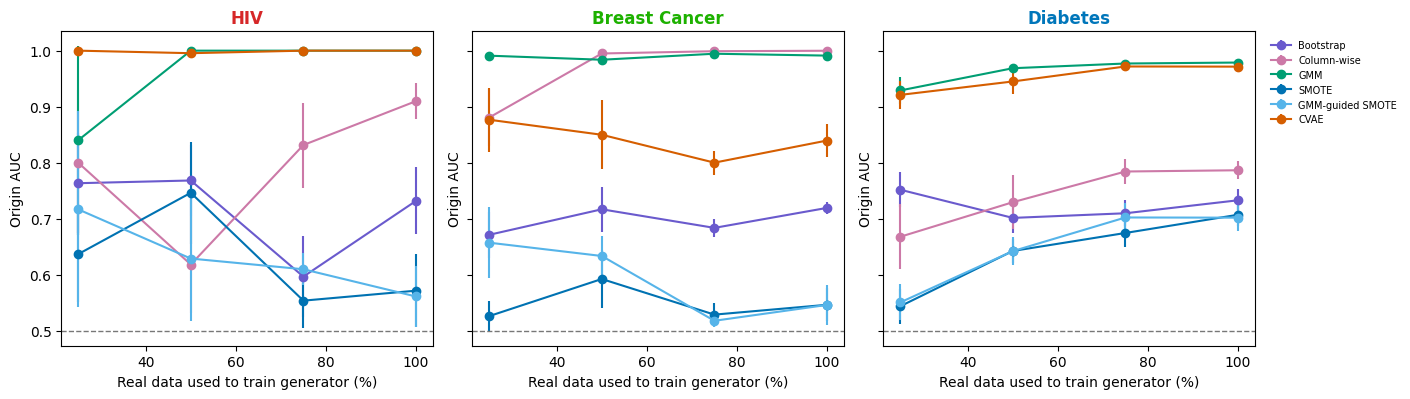

,dataset,method,fraction,mean,std
0,Breast Cancer,Bootstrap,0.25,0.671190,0.040532
1,Breast Cancer,Bootstrap,0.50,0.716763,0.040197
2,Breast Cancer,Bootstrap,0.75,0.683566,0.016484
3,Breast Cancer,Bootstrap,1.00,0.719255,0.011204
4,Breast Cancer,CVAE,0.25,0.876667,0.057466
...,...,...,...,...,...
67,HIV,GMM-guided SMOTE,1.00,0.561059,0.055277
68,HIV,SMOTE,0.25,0.636667,0.085310
69,HIV,SMOTE,0.50,0.746212,0.090593
70,HIV,SMOTE,0.75,0.553633,0.048797


In [12]:
sample_size_table = cached(
    "sample_size",
    lambda: followup.compute_sample_size_sensitivity(
        datasets, methods=METHODS,
        fractions=(0.25, 0.5, 0.75, 1.0),
        repeats=cfg["sample_repeats"], seed=SEED,
        cvae_epochs=cfg["sample_cvae_epochs"],
    ),
)
fig_sample_size, sample_size_summary = followup.plot_sample_size_sensitivity(sample_size_table)
plt.show()
display(sample_size_summary)

## Export result tables

In [13]:
export_dir = pkg_root / "notebooks" / "followup_exports"
export_dir.mkdir(parents=True, exist_ok=True)
tables = {
    "feature_kld": feature_kld,
    "origin_auc_runs": auc_runs,
    "metric_table": metric_table,
    "structure_metrics": structure_table,
    "marginal_tests": marginal_tests,
    "marginal_summary": marginal_summary,
    "noise_sensitivity": noise_table,
    "reverse_ablation": ablation_table,
    "sample_size_sensitivity": sample_size_table,
}
for name, table in tables.items():
    table.to_csv(export_dir / f"{name}_{RUN_MODE}.csv", index=False)
print(f"Exported {len(tables)} tables to {export_dir}")

Exported 9 tables to C:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\notebooks\followup_exports
